# VAE + TFT Transfer Learning for Battery RUL

This notebook runs transfer learning in both directions:

1. HNEI -> NASA
2. NASA -> HNEI

For each direction, the workflow is:

1. Train a VAE on the source-domain feature windows.
2. Freeze the VAE encoder and use it to create latent degradation features for source and target batteries.
3. Train a TFT RUL model on the source domain with raw features plus frozen VAE latent features.
4. Evaluate zero-shot transfer on the target test batteries.
5. Fine-tune the TFT on a small target-domain training subset and evaluate on held-out target batteries.

The VAE encoder is not updated during target fine-tuning. Only the TFT is fine-tuned on the target domain.


In [29]:
# If the imports below fail, uncomment and run this cell once.
# %pip install -q lightning pytorch-forecasting


In [30]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import matplotlib.pyplot as plt

SEED = 42
seed_everything(SEED, workers=True)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


Seed set to 42


Using device: mps


In [31]:
HNEI_DATA_PATH = Path("Battery_RUL_Cleaned.csv")
NASA_DATA_PATH = Path("nasa_battery_cycles.csv")
DATA_PATHS = {"hnei": HNEI_DATA_PATH, "nasa": NASA_DATA_PATH}
CHECKPOINT_DIR = Path("model_checkpoints")
FIGURE_DIR = Path("figures")
MODEL_TARGET_COL = "target_scaled"

RENAMES = {
    "Cycle_Index": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target",
}

RAW_FEATURE_COLS = [
    "discharge_time",
    "decrement_36_34",
    "max_voltage_discharge",
    "min_voltage_charge",
    "time_at_415",
    "time_constant_current",
    "charging_time",
]

# Keep VAE_WINDOW_LENGTH aligned with TFT history length so each latent describes
# the same recent degradation context the TFT sees.
VAE_WINDOW_LENGTH = 20
MAX_ENCODER_LENGTH = 20
MAX_PREDICTION_LENGTH = 1

LATENT_DIM = 8
VAE_HIDDEN_SIZE = 64
VAE_BATCH_SIZE = 256
VAE_EPOCHS = 20
VAE_LR = 1e-3
VAE_BETA = 1e-3

TFT_BATCH_SIZE = 64
TFT_SOURCE_EPOCHS = 15
TFT_TRANSFER_EPOCHS = 6
# Target-only starts from random weights, so give it a larger early-stopped budget while keeping the same target batteries.
TFT_TARGET_ONLY_EPOCHS = 20
TFT_SOURCE_LR = 3e-2
TFT_HIDDEN_SIZE = 16
TFT_DROPOUT = 0.2
TFT_TRANSFER_LR = 1e-4

# Fraction of target-domain training batteries used for fine-tuning.
# Increase to 1.0 if you want full-target fine-tuning instead of the small-data setup.
TARGET_TRAIN_FRACTION = 0.35

# False matches the VAE-transfer idea: raw features -> frozen VAE encoder -> latent -> TFT head -> normalized RUL.
# Set True for a hybrid TFT that sees both raw cycle features and frozen VAE latents.
USE_RAW_FEATURES_IN_TFT = False

# RUL cannot be negative; clipping is applied only after converting predictions back to cycles.
CLIP_NEGATIVE_RUL_PREDICTIONS = True

# Fine-tuning mode: "head_only" freezes the TFT backbone and updates the final prediction head only.
FINETUNE_MODE = "head_only"
MAIN_DIRECTION = ("nasa", "hnei")
SUPPLEMENTARY_DIRECTIONS = [("hnei", "nasa")]


## Load and Split Batteries

`Is_NASA == 0` is treated as HNEI and `Is_NASA == 1` is treated as NASA. Splits are done at the battery level so the model is tested on unseen batteries, not later cycles from batteries it already saw.


In [32]:
def load_single_domain_dataframe(path: Path, domain: str) -> pd.DataFrame:
    domain_df = pd.read_csv(path).rename(columns=RENAMES).reset_index(drop=True)
    required_cols = ["time_idx", "target", *RAW_FEATURE_COLS]
    missing_cols = [col for col in required_cols if col not in domain_df.columns]
    if missing_cols:
        raise ValueError(f"{path} is missing required columns: {missing_cols}")

    domain_df["domain"] = domain

    # Each file is ordered by battery, and a new battery starts when cycle index resets to 1.
    segment_id = (domain_df["time_idx"] == 1).cumsum() - 1
    domain_df["battery_id"] = domain + "_" + segment_id.astype(str)

    domain_df = domain_df.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)
    domain_df["battery_id"] = domain_df["battery_id"].astype(str)
    domain_df["time_idx"] = domain_df["time_idx"].astype(int)
    domain_df["target"] = domain_df["target"].astype(float)
    for col in RAW_FEATURE_COLS:
        domain_df[col] = domain_df[col].astype(float)
    return domain_df


def load_battery_dataframe(paths: dict[str, Path]) -> pd.DataFrame:
    frames = [load_single_domain_dataframe(paths[domain], domain) for domain in ["hnei", "nasa"]]
    return pd.concat(frames, ignore_index=True).sort_values(["domain", "battery_id", "time_idx"]).reset_index(drop=True)


def summarize_domains(df: pd.DataFrame) -> pd.DataFrame:
    per_battery = df.groupby(["domain", "battery_id"]).agg(
        rows=("time_idx", "size"),
        min_cycle=("time_idx", "min"),
        max_cycle=("time_idx", "max"),
        min_rul=("target", "min"),
        median_rul=("target", "median"),
        max_rul=("target", "max"),
    )
    return per_battery.groupby("domain").agg(
        batteries=("rows", "count"),
        rows=("rows", "sum"),
        min_len=("rows", "min"),
        median_len=("rows", "median"),
        max_len=("rows", "max"),
        min_rul=("min_rul", "min"),
        median_rul=("median_rul", "median"),
        max_rul=("max_rul", "max"),
    )


df = load_battery_dataframe(DATA_PATHS)
print(df.shape)
print(f"Loaded HNEI from {HNEI_DATA_PATH} and NASA from {NASA_DATA_PATH}")
display(df.head())
display(summarize_domains(df))


(17658, 11)
Loaded HNEI from Battery_RUL_Cleaned.csv and NASA from nasa_battery_cycles.csv


,time_idx,discharge_time,decrement_36_34,max_voltage_discharge,min_voltage_charge,time_at_415,time_constant_current,charging_time,target,domain,battery_id
0,1,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1062.0,hnei,hnei_0
1,2,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1061.0,hnei,hnei_0
2,3,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1060.0,hnei,hnei_0
3,4,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1059.0,hnei,hnei_0
4,5,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1058.0,hnei,hnei_0


,batteries,rows,min_len,median_len,max_len,min_rul,median_rul,max_rul
domain,,,,,,,,
hnei,14,14874,1039,1065.0,1067,0.0,532.00,1066.0
nasa,34,2784,24,68.5,197,0.0,34.25,196.0


In [33]:
def split_domain_by_battery(
    df: pd.DataFrame,
    domain: str,
    test_size: float = 0.20,
    val_size_of_remaining: float = 0.20,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    domain_df = df[df["domain"] == domain].copy()
    battery_ids = np.array(sorted(domain_df["battery_id"].unique()))

    train_val_ids, test_ids = train_test_split(
        battery_ids, test_size=test_size, random_state=seed, shuffle=True
    )
    train_ids, val_ids = train_test_split(
        train_val_ids, test_size=val_size_of_remaining, random_state=seed, shuffle=True
    )

    train_df = domain_df[domain_df["battery_id"].isin(train_ids)].copy()
    val_df = domain_df[domain_df["battery_id"].isin(val_ids)].copy()
    test_df = domain_df[domain_df["battery_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df


def keep_fraction_of_batteries(
    domain_train_df: pd.DataFrame,
    fraction: float,
    seed: int = SEED,
) -> pd.DataFrame:
    if fraction >= 1.0:
        return domain_train_df.copy()
    battery_ids = np.array(sorted(domain_train_df["battery_id"].unique()))
    n_keep = max(1, math.ceil(len(battery_ids) * fraction))
    rng = np.random.default_rng(seed)
    keep_ids = rng.choice(battery_ids, size=n_keep, replace=False)
    return domain_train_df[domain_train_df["battery_id"].isin(keep_ids)].copy()


def battery_numeric_suffix(battery_id: str) -> int:
    return int(str(battery_id).split("_")[-1])


def get_last_battery_id(data: pd.DataFrame, domain: str) -> str:
    ids = sorted(data.loc[data["domain"] == domain, "battery_id"].unique(), key=battery_numeric_suffix)
    if not ids:
        raise ValueError(f"No batteries found for domain={domain!r}")
    return ids[-1]


def remove_batteries(data: pd.DataFrame, battery_ids: set[str]) -> pd.DataFrame:
    return data[~data["battery_id"].isin(battery_ids)].copy()


def build_feature_scaler(fit_df: pd.DataFrame, feature_cols: list[str], label: str) -> dict[str, object]:
    """Fit input feature standardization from training batteries only."""
    means = fit_df[feature_cols].mean().astype(float)
    stds = fit_df[feature_cols].std(ddof=0).replace(0, 1.0).astype(float)
    return {
        "label": label,
        "feature_cols": tuple(feature_cols),
        "mean": means.to_dict(),
        "std": stds.to_dict(),
        "fit_battery_ids": tuple(sorted(fit_df["battery_id"].astype(str).unique())),
        "fit_rows": int(len(fit_df)),
    }


def apply_feature_scaler(data: pd.DataFrame, scaler: dict[str, object]) -> pd.DataFrame:
    result = data.copy()
    for col in scaler["feature_cols"]:
        result[col] = (result[col] - scaler["mean"][col]) / scaler["std"][col]
    return result


def build_target_scaler(fit_df: pd.DataFrame, label: str) -> dict[str, object]:
    """Fit a target scaler from training data only."""
    target_min = float(fit_df["target"].min())
    target_max = float(fit_df["target"].max())
    if target_max <= target_min:
        raise ValueError(f"Invalid target range for {label}: {target_min}, {target_max}")
    return {
        "label": label,
        "target_min": target_min,
        "target_max": target_max,
        "target_range": target_max - target_min,
        "fit_battery_ids": tuple(sorted(fit_df["battery_id"].astype(str).unique())),
        "fit_rows": int(len(fit_df)),
    }


def add_normalized_columns(data: pd.DataFrame, scaler: dict[str, object]) -> pd.DataFrame:
    result = data.copy()
    result[MODEL_TARGET_COL] = (result["target"] - scaler["target_min"]) / scaler["target_range"]
    return result


def inverse_target_scale(values_scaled: np.ndarray, scaler: dict[str, object]) -> np.ndarray:
    return values_scaled * scaler["target_range"] + scaler["target_min"]


def battery_id_set(data: pd.DataFrame) -> set[str]:
    return set(data["battery_id"].astype(str).unique())


def assert_disjoint_batteries(label: str, *parts: tuple[str, pd.DataFrame]) -> None:
    seen: dict[str, set[str]] = {}
    for name, data in parts:
        ids = battery_id_set(data)
        for other_name, other_ids in seen.items():
            overlap = ids & other_ids
            if overlap:
                raise AssertionError(
                    f"Battery leakage in {label}: {name} overlaps {other_name}: {sorted(overlap)}"
                )
        seen[name] = ids
    counts = ", ".join(f"{name}={len(ids)}" for name, ids in seen.items())
    print(f"Leakage check passed for {label}: {counts}")


def assert_no_simulation_batteries(label: str, *parts: tuple[str, pd.DataFrame]) -> None:
    sim_ids = set(simulation_battery_ids.values())
    for name, data in parts:
        overlap = battery_id_set(data) & sim_ids
        if overlap:
            raise AssertionError(f"Simulation battery leakage in {label}: {name} contains {sorted(overlap)}")
    print(f"Simulation exclusion check passed for {label}: excluded={sorted(sim_ids)}")


def assert_scaler_from_training_only(
    label: str,
    scaler: dict[str, object],
    fit_df: pd.DataFrame,
    *forbidden_parts: tuple[str, pd.DataFrame],
) -> None:
    expected_ids = tuple(sorted(fit_df["battery_id"].astype(str).unique()))
    if tuple(scaler["fit_battery_ids"]) != expected_ids:
        raise AssertionError(f"Scaler {label} was not fit on the expected training batteries")
    if not np.isclose(float(scaler["target_min"]), float(fit_df["target"].min())):
        raise AssertionError(f"Scaler {label} target_min does not match training data")
    if not np.isclose(float(scaler["target_max"]), float(fit_df["target"].max())):
        raise AssertionError(f"Scaler {label} target_max does not match training data")
    fit_ids = set(expected_ids)
    for name, data in forbidden_parts:
        overlap = fit_ids & battery_id_set(data)
        if overlap:
            raise AssertionError(f"Scaler {label} fit batteries overlap forbidden {name}: {sorted(overlap)}")
    print(
        f"Scaler check passed for {label}: fit_rows={scaler['fit_rows']}, "
        f"fit_batteries={list(expected_ids)}, "
        f"range=[{scaler['target_min']:.2f}, {scaler['target_max']:.2f}]"
    )


def assert_target_scaler_from_training_only(
    label: str,
    scaler: dict[str, object],
    fit_df: pd.DataFrame,
    *forbidden_parts: tuple[str, pd.DataFrame],
) -> None:
    return assert_scaler_from_training_only(label, scaler, fit_df, *forbidden_parts)


def assert_feature_scaler_from_training_only(
    label: str,
    scaler: dict[str, object],
    fit_df: pd.DataFrame,
    *forbidden_parts: tuple[str, pd.DataFrame],
) -> None:
    expected_ids = tuple(sorted(fit_df["battery_id"].astype(str).unique()))
    if tuple(scaler["fit_battery_ids"]) != expected_ids:
        raise AssertionError(f"Feature scaler {label} was not fit on the expected training batteries")
    for col in scaler["feature_cols"]:
        if not np.isclose(float(scaler["mean"][col]), float(fit_df[col].mean())):
            raise AssertionError(f"Feature scaler {label} mean mismatch for {col}")
        expected_std = float(fit_df[col].std(ddof=0)) or 1.0
        if not np.isclose(float(scaler["std"][col]), expected_std):
            raise AssertionError(f"Feature scaler {label} std mismatch for {col}")
    fit_ids = set(expected_ids)
    for name, data in forbidden_parts:
        overlap = fit_ids & battery_id_set(data)
        if overlap:
            raise AssertionError(f"Feature scaler {label} fit batteries overlap forbidden {name}: {sorted(overlap)}")
    print(
        f"Feature scaler check passed for {label}: fit_rows={scaler['fit_rows']}, "
        f"fit_batteries={list(expected_ids)}"
    )


simulation_battery_ids = {
    domain: get_last_battery_id(df, domain)
    for domain in ["hnei", "nasa"]
}
simulation_battery_id_set = set(simulation_battery_ids.values())
simulation_sets = {
    domain: df[df["battery_id"] == battery_id].copy()
    for domain, battery_id in simulation_battery_ids.items()
}

# Keep the original split assignments by splitting on all batteries first, then
# removing the reserved simulation batteries from whichever split they landed in.
raw_splits = {
    domain: split_domain_by_battery(df, domain)
    for domain in ["hnei", "nasa"]
}
splits = {
    domain: tuple(remove_batteries(part, simulation_battery_id_set) for part in parts)
    for domain, parts in raw_splits.items()
}

print("Reserved simulation batteries:")
for domain, battery_id in simulation_battery_ids.items():
    sim = simulation_sets[domain]
    print(
        f"  {domain.upper()}: {battery_id}, rows={len(sim)}, "
        f"cycles=[{sim['time_idx'].min()}, {sim['time_idx'].max()}], "
        f"RUL=[{sim['target'].min():.1f}, {sim['target'].max():.1f}]"
    )

print("\nModeling splits after simulation holdout:")
for domain, (train_df, val_df, test_df) in splits.items():
    assert_disjoint_batteries(
        f"{domain} train/val/test",
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
        ("simulation", simulation_sets[domain]),
    )
    assert_no_simulation_batteries(
        f"{domain} modeling splits",
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    )
    print(f"{domain.upper()}")
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df), ("simulation", simulation_sets[domain])]:
        print(
            f"  {split_name:10s}: rows={len(split_df):5d}, batteries={split_df['battery_id'].nunique():2d}, "
            f"ids={sorted(split_df['battery_id'].unique())}"
        )


Reserved simulation batteries:
  HNEI: hnei_13, rows=1039, cycles=[1, 1039], RUL=[0.0, 1038.0]
  NASA: nasa_33, rows=102, cycles=[1, 102], RUL=[0.0, 101.0]

Modeling splits after simulation holdout:
Leakage check passed for hnei train/val/test: train=7, val=3, test=3, simulation=1
Simulation exclusion check passed for hnei modeling splits: excluded=['hnei_13', 'nasa_33']
HNEI
  train     : rows= 7447, batteries= 7, ids=['hnei_1', 'hnei_10', 'hnei_12', 'hnei_2', 'hnei_3', 'hnei_4', 'hnei_6']
  val       : rows= 3197, batteries= 3, ids=['hnei_11', 'hnei_8', 'hnei_9']
  test      : rows= 3191, batteries= 3, ids=['hnei_0', 'hnei_5', 'hnei_7']
  simulation: rows= 1039, batteries= 1, ids=['hnei_13']
Leakage check passed for nasa train/val/test: train=21, val=6, test=6, simulation=1
Simulation exclusion check passed for nasa modeling splits: excluded=['hnei_13', 'nasa_33']
NASA
  train     : rows= 1861, batteries=21, ids=['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_1

## VAE Encoder

The VAE sees only raw cycle-level features. After source-domain VAE training, the encoder is frozen and used as a latent feature generator for both source and target domains.


In [34]:
class FeatureWindowDataset(Dataset):
    def __init__(self, data: pd.DataFrame, feature_cols: list[str], window_length: int):
        windows = []
        for _, group in data.groupby("battery_id", sort=False):
            values = group[feature_cols].to_numpy(dtype=np.float32)
            if len(values) < 2:
                continue
            for end in range(len(values)):
                start = max(0, end - window_length + 1)
                window = values[start : end + 1]
                if len(window) < window_length:
                    pad = np.repeat(window[:1], window_length - len(window), axis=0)
                    window = np.vstack([pad, window])
                windows.append(window)
        self.windows = torch.tensor(np.stack(windows), dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.windows[idx]


class SequenceVAE(nn.Module):
    def __init__(self, num_features: int, hidden_size: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.GRU(num_features, hidden_size, batch_first=True)
        self.mu = nn.Linear(hidden_size, latent_dim)
        self.logvar = nn.Linear(hidden_size, latent_dim)

        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size)
        self.decoder = nn.GRU(num_features, hidden_size, batch_first=True)
        self.reconstruction = nn.Linear(hidden_size, num_features)

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        _, h = self.encoder(x)
        h = h[-1]
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor, seq_len: int, num_features: int) -> torch.Tensor:
        h0 = self.latent_to_hidden(z).unsqueeze(0)
        decoder_input = torch.zeros(z.size(0), seq_len, num_features, device=z.device)
        decoded, _ = self.decoder(decoder_input, h0)
        return self.reconstruction(decoded)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, x.size(1), x.size(2))
        return recon, mu, logvar


def vae_loss(
    recon: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = VAE_BETA,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    reconstruction_loss = nn.functional.mse_loss(recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = reconstruction_loss + beta * kl_loss
    return total, reconstruction_loss, kl_loss


def next_available_path(path: Path) -> Path:
    if not path.exists():
        return path
    for version in range(2, 10_000):
        candidate = path.with_name(f"{path.stem}_v{version}{path.suffix}")
        if not candidate.exists():
            return candidate
    raise RuntimeError(f"Could not find an available checkpoint path for {path}")


def train_vae(source_train_df: pd.DataFrame, direction_name: str) -> SequenceVAE:
    dataset = FeatureWindowDataset(source_train_df, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH)
    loader = DataLoader(dataset, batch_size=VAE_BATCH_SIZE, shuffle=True, num_workers=0)

    model = SequenceVAE(
        num_features=len(RAW_FEATURE_COLS),
        hidden_size=VAE_HIDDEN_SIZE,
        latent_dim=LATENT_DIM,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=VAE_LR)

    history = []
    for epoch in range(1, VAE_EPOCHS + 1):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0
        n_seen = 0
        for batch in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            total, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar)
            total.backward()
            optimizer.step()

            batch_size = batch.size(0)
            running_total += total.item() * batch_size
            running_recon += recon_loss.item() * batch_size
            running_kl += kl_loss.item() * batch_size
            n_seen += batch_size

        row = {
            "epoch": epoch,
            "loss": running_total / n_seen,
            "reconstruction_loss": running_recon / n_seen,
            "kl_loss": running_kl / n_seen,
        }
        history.append(row)
        if epoch == 1 or epoch % 5 == 0 or epoch == VAE_EPOCHS:
            print(
                f"[{direction_name} VAE] epoch {epoch:02d}/{VAE_EPOCHS} "
                f"loss={row['loss']:.5f} recon={row['reconstruction_loss']:.5f} kl={row['kl_loss']:.5f}"
            )

    model.history_ = pd.DataFrame(history)
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    vae_checkpoint_path = next_available_path(CHECKPOINT_DIR / f"vae_{direction_name}.pt")
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": model.history_,
            "feature_cols": RAW_FEATURE_COLS,
            "window_length": VAE_WINDOW_LENGTH,
            "latent_dim": LATENT_DIM,
            "hidden_size": VAE_HIDDEN_SIZE,
            "direction": direction_name,
        },
        vae_checkpoint_path,
    )
    model.checkpoint_path_ = str(vae_checkpoint_path)
    print(f"Saved VAE checkpoint to {vae_checkpoint_path}")
    return model


In [35]:
@torch.no_grad()
def add_frozen_vae_latents(
    data: pd.DataFrame,
    vae: SequenceVAE,
    feature_cols: list[str],
    window_length: int,
    latent_dim: int,
    batch_size: int = 1024,
) -> tuple[pd.DataFrame, list[str]]:
    vae.eval()
    windows = []
    row_indices = []

    for _, group in data.groupby("battery_id", sort=False):
        values = group[feature_cols].to_numpy(dtype=np.float32)
        indices = group.index.to_numpy()
        for pos, idx in enumerate(indices):
            start = max(0, pos - window_length + 1)
            window = values[start : pos + 1]
            if len(window) < window_length:
                pad = np.repeat(window[:1], window_length - len(window), axis=0)
                window = np.vstack([pad, window])
            windows.append(window)
            row_indices.append(idx)

    latent_chunks = []
    for start in range(0, len(windows), batch_size):
        batch = torch.tensor(np.stack(windows[start : start + batch_size]), dtype=torch.float32, device=DEVICE)
        mu, _ = vae.encode(batch)
        latent_chunks.append(mu.cpu().numpy())

    latents = np.vstack(latent_chunks)
    latent_cols = [f"vae_latent_{i:02d}" for i in range(latent_dim)]

    result = data.copy()
    for col in latent_cols:
        result[col] = np.nan
    result.loc[row_indices, latent_cols] = latents
    result[latent_cols] = result[latent_cols].astype(float)
    return result, latent_cols


## TFT Helpers

The TFT predicts normalized RUL (`target_scaled`) instead of raw cycle counts. Each direction fits target min-max scalers from training data only: source train for source evaluation, and the target fine-tune batteries for target evaluation. Input feature standardization is also fit from training batteries only: source train for the source VAE/TFT transfer path, and target fine-tune batteries for the target-only baseline.

Raw `time_idx` is kept only as the PyTorch Forecasting sequence index. It is not passed as a known or unknown real-valued model feature. `add_relative_time_idx=True` provides relative order inside the order-based sliding window.


In [36]:
def attach_prediction_index(dataset: TimeSeriesDataSet, data: pd.DataFrame) -> TimeSeriesDataSet:
    group_order = list(data.groupby("battery_id", sort=False).groups.keys())
    index = dataset.index.copy().reset_index(drop=True)
    prediction_index = pd.DataFrame({
        "battery_id": index["sequence_id"].map(lambda value: str(group_order[int(value)])),
        "time_idx": (index["time"] + index["sequence_length"] - dataset.max_prediction_length).astype(int),
    })
    dataset.prediction_index_ = prediction_index
    return dataset


def make_tft_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    unknown_reals: list[str],
) -> tuple[TimeSeriesDataSet, TimeSeriesDataSet, TimeSeriesDataSet]:
    print(f"TFT unknown reals: {unknown_reals}")
    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=MODEL_TARGET_COL,
        group_ids=["battery_id"],
        categorical_encoders={
            "battery_id": NaNLabelEncoder(add_nan=True),
            "__group_id__battery_id": NaNLabelEncoder(add_nan=True),
        },
        min_encoder_length=1,
        max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=MAX_PREDICTION_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=[],
        static_reals=[],
        time_varying_known_reals=[],
        time_varying_unknown_reals=unknown_reals,
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        target_normalizer=None,
        allow_missing_timesteps=True,
    )
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False, stop_randomization=True)
    test = TimeSeriesDataSet.from_dataset(training, test_df, predict=False, stop_randomization=True)
    attach_prediction_index(training, train_df)
    attach_prediction_index(validation, val_df)
    attach_prediction_index(test, test_df)
    return training, validation, test


def make_source_tft_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    latent_cols: list[str],
) -> tuple[TimeSeriesDataSet, TimeSeriesDataSet, TimeSeriesDataSet]:
    transfer_reals = (RAW_FEATURE_COLS if USE_RAW_FEATURES_IN_TFT else []) + latent_cols
    return make_tft_datasets(train_df, val_df, test_df, transfer_reals)


def make_raw_tft_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> tuple[TimeSeriesDataSet, TimeSeriesDataSet, TimeSeriesDataSet]:
    return make_tft_datasets(train_df, val_df, test_df, RAW_FEATURE_COLS)


def make_transfer_dataset(
    source_training: TimeSeriesDataSet,
    target_df: pd.DataFrame,
) -> TimeSeriesDataSet:
    dataset = TimeSeriesDataSet.from_dataset(
        source_training,
        target_df,
        predict=False,
        stop_randomization=True,
    )
    attach_prediction_index(dataset, target_df)
    return dataset


def make_dataloader(dataset: TimeSeriesDataSet, train: bool) -> DataLoader:
    return dataset.to_dataloader(train=train, batch_size=TFT_BATCH_SIZE, num_workers=0)


def print_tft_sample_shape(dataset: TimeSeriesDataSet, label: str) -> None:
    x, y = dataset[0]
    y_tensor = y[0] if isinstance(y, tuple) else y
    print(
        f"{label} sample: x_cont_shape={tuple(x['x_cont'].shape)}, "
        f"encoder_length={int(x['encoder_length'])}, decoder_length={int(x['decoder_length'])}, "
        f"target_shape={tuple(y_tensor.shape)}, reals={dataset.reals}"
    )


def build_tft(training: TimeSeriesDataSet, learning_rate: float) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=TFT_HIDDEN_SIZE,
        attention_head_size=2,
        dropout=TFT_DROPOUT,
        hidden_continuous_size=8,
        output_size=1,
        loss=RMSE(),
        reduce_on_plateau_patience=3,
    )


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def configure_tft_finetuning(model: TemporalFusionTransformer, mode: str = FINETUNE_MODE) -> TemporalFusionTransformer:
    if mode == "all":
        for param in model.parameters():
            param.requires_grad = True
    elif mode == "head_only":
        for param in model.parameters():
            param.requires_grad = False
        trainable = 0
        for name, param in model.named_parameters():
            if "output_layer" in name:
                param.requires_grad = True
                trainable += param.numel()
        if trainable == 0:
            print("No output_layer parameters found; falling back to full TFT fine-tuning.")
            for param in model.parameters():
                param.requires_grad = True
    else:
        raise ValueError(f"Unsupported FINETUNE_MODE={mode!r}")
    print(f"Fine-tuning mode={mode}; trainable parameters={count_trainable_parameters(model):,}")
    return model


def fit_tft(
    model: TemporalFusionTransformer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int,
    experiment_name: str,
) -> TemporalFusionTransformer:
    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-4,
        patience=3,
        mode="min",
    )
    checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename=f"{experiment_name}-{{epoch:02d}}-{{val_loss:.4f}}",
    )
    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[early_stop, checkpoint_callback],
        logger=CSVLogger("lightning_logs", name=experiment_name),
        enable_checkpointing=True,
        log_every_n_steps=10,
    )
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    model.best_checkpoint_path_ = checkpoint_callback.best_model_path
    model.last_checkpoint_path_ = checkpoint_callback.last_model_path
    print(f"Best TFT checkpoint for {experiment_name}: {checkpoint_callback.best_model_path}")
    print(f"Last TFT checkpoint for {experiment_name}: {checkpoint_callback.last_model_path}")
    return model


def prediction_index_from_loader(loader: DataLoader) -> pd.DataFrame:
    dataset = loader.dataset
    if not hasattr(dataset, "prediction_index_"):
        raise ValueError("Prediction dataset is missing prediction_index_; create it with make_tft_datasets or make_transfer_dataset")
    index = dataset.prediction_index_.reset_index(drop=True).copy()
    index["battery_id"] = index["battery_id"].astype(str)
    index["time_idx"] = index["time_idx"].astype(int)
    return index


def evaluate_tft(
    model: TemporalFusionTransformer,
    loader: DataLoader,
    label: str,
    scaler: dict[str, object],
    direction: str,
    stage: str,
) -> dict[str, float | str | np.ndarray | pd.DataFrame]:
    predictions_scaled = model.predict(loader)
    actuals_scaled = torch.cat([y[0] for _, y in iter(loader)])

    preds_scaled = np.atleast_1d(predictions_scaled.squeeze().detach().cpu().numpy())
    acts_scaled = np.atleast_1d(actuals_scaled.squeeze().detach().cpu().numpy())

    preds = inverse_target_scale(preds_scaled, scaler)
    acts = inverse_target_scale(acts_scaled, scaler)
    if CLIP_NEGATIVE_RUL_PREDICTIONS:
        preds = np.maximum(preds, 0.0)

    prediction_df = prediction_index_from_loader(loader).iloc[: len(preds)].copy()
    prediction_df["true_rul"] = acts
    prediction_df["pred_rul"] = preds
    prediction_df["true_rul_scaled"] = acts_scaled
    prediction_df["pred_rul_scaled"] = preds_scaled
    prediction_df["direction"] = direction
    prediction_df["stage"] = stage

    metrics = {
        "label": label,
        "direction": direction,
        "stage": stage,
        "target_min": scaler["target_min"],
        "target_max": scaler["target_max"],
        "mae": mean_absolute_error(acts, preds),
        "rmse": np.sqrt(mean_squared_error(acts, preds)),
        "r2": r2_score(acts, preds),
        "mae_scaled": mean_absolute_error(acts_scaled, preds_scaled),
        "rmse_scaled": np.sqrt(mean_squared_error(acts_scaled, preds_scaled)),
        "r2_scaled": r2_score(acts_scaled, preds_scaled),
        "preds": preds,
        "actuals": acts,
        "preds_scaled": preds_scaled,
        "actuals_scaled": acts_scaled,
        "prediction_df": prediction_df,
    }
    print(
        f"{label}: MAE={metrics['mae']:.4f} cycles, "
        f"RMSE={metrics['rmse']:.4f} cycles, R2={metrics['r2']:.4f}; "
        f"scaled_RMSE={metrics['rmse_scaled']:.4f}, "
        f"target_range=[{scaler['target_min']:.1f}, {scaler['target_max']:.1f}]"
    )
    return metrics


def load_best_tft_checkpoint(checkpoint_path: str | Path) -> TemporalFusionTransformer:
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)
    return TemporalFusionTransformer.load_from_checkpoint(str(checkpoint_path))


def load_saved_vae_checkpoint(checkpoint_path: str | Path, map_location: torch.device | str = DEVICE) -> SequenceVAE:
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)
    payload = torch.load(checkpoint_path, map_location=map_location)
    model = SequenceVAE(
        num_features=len(payload.get("feature_cols", RAW_FEATURE_COLS)),
        hidden_size=int(payload.get("hidden_size", VAE_HIDDEN_SIZE)),
        latent_dim=int(payload.get("latent_dim", LATENT_DIM)),
    ).to(map_location)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    model.history_ = payload.get("history")
    model.checkpoint_path_ = str(checkpoint_path)
    return model


## Run One Transfer Direction

This function performs the full source-to-target transfer experiment and a matched no-transfer baseline.

For each direction it reports:

1. Source-domain test performance.
2. Zero-shot target performance from the source-trained TFT.
3. Transfer + fine-tuning on the small target subset.
4. Target-only small-data baseline trained from scratch on the same target subset.


In [37]:
def run_transfer_direction(source_domain: str, target_domain: str) -> dict[str, object]:
    direction_name = f"{source_domain}_to_{target_domain}"
    print("=" * 80)
    print(f"Running {source_domain.upper()} -> {target_domain.upper()}")

    source_train, source_val, source_test = splits[source_domain]
    target_train_full, target_val, target_test = splits[target_domain]
    target_simulation = simulation_sets[target_domain]
    target_train_small = keep_fraction_of_batteries(
        target_train_full,
        TARGET_TRAIN_FRACTION,
        seed=SEED,
    )

    # Fit all scalers only from training batteries used in this direction.
    source_feature_scaler = build_feature_scaler(source_train, RAW_FEATURE_COLS, f"{direction_name}_source_features")
    target_feature_scaler = build_feature_scaler(target_train_small, RAW_FEATURE_COLS, f"{direction_name}_target_features")
    source_scaler = build_target_scaler(source_train, f"{direction_name}_source_train")
    target_scaler = build_target_scaler(target_train_small, f"{direction_name}_target_finetune")

    assert_disjoint_batteries(
        f"{direction_name} source split",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_disjoint_batteries(
        f"{direction_name} target split",
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )
    assert_no_simulation_batteries(
        f"{direction_name} all modeling data",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} source feature scaler",
        source_feature_scaler,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} target feature scaler",
        target_feature_scaler,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} source target scaler",
        source_scaler,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} target target scaler",
        target_scaler,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )

    target_train_ids = sorted(target_train_small["battery_id"].unique())
    target_test_ids = sorted(target_test["battery_id"].unique())
    print(
        f"Target fine-tuning/baseline batteries: "
        f"{len(target_train_ids)} / {target_train_full['battery_id'].nunique()}"
    )
    print(f"Target train batteries used by both methods: {target_train_ids}")
    print(f"Held-out target test batteries used by both methods: {target_test_ids}")
    print(f"Source feature scaler fit batteries: {list(source_feature_scaler['fit_battery_ids'])}")
    print(f"Target feature scaler fit batteries: {list(target_feature_scaler['fit_battery_ids'])}")
    print(
        f"Source target scaler fit: {source_scaler['label']}, "
        f"batteries={list(source_scaler['fit_battery_ids'])}, "
        f"range=[{source_scaler['target_min']:.1f}, {source_scaler['target_max']:.1f}] cycles"
    )
    print(
        f"Target target scaler fit: {target_scaler['label']}, "
        f"batteries={list(target_scaler['fit_battery_ids'])}, "
        f"range=[{target_scaler['target_min']:.1f}, {target_scaler['target_max']:.1f}] cycles"
    )

    # Transfer path uses the source feature scaler because the frozen source VAE
    # and source TFT see source-domain standardized features/latents.
    source_train_features = apply_feature_scaler(source_train, source_feature_scaler)
    source_val_features = apply_feature_scaler(source_val, source_feature_scaler)
    source_test_features = apply_feature_scaler(source_test, source_feature_scaler)
    target_train_transfer_features = apply_feature_scaler(target_train_small, source_feature_scaler)
    target_val_transfer_features = apply_feature_scaler(target_val, source_feature_scaler)
    target_test_transfer_features = apply_feature_scaler(target_test, source_feature_scaler)
    target_sim_transfer_features = apply_feature_scaler(target_simulation, source_feature_scaler)

    # Target-only baseline uses target-domain feature scaling fit on the same fine-tune batteries.
    target_train_baseline_features = apply_feature_scaler(target_train_small, target_feature_scaler)
    target_val_baseline_features = apply_feature_scaler(target_val, target_feature_scaler)
    target_test_baseline_features = apply_feature_scaler(target_test, target_feature_scaler)
    target_sim_baseline_features = apply_feature_scaler(target_simulation, target_feature_scaler)

    # ------------------------------------------------------------------
    # 1. Proposed path: source VAE + source TFT, then target fine-tuning
    # ------------------------------------------------------------------
    source_vae = train_vae(source_train_features, direction_name)
    for param in source_vae.encoder.parameters():
        param.requires_grad = False
    for param in source_vae.mu.parameters():
        param.requires_grad = False
    for param in source_vae.logvar.parameters():
        param.requires_grad = False

    source_train_lat, source_latent_cols = add_frozen_vae_latents(
        source_train_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    source_val_lat, _ = add_frozen_vae_latents(
        source_val_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    source_test_lat, _ = add_frozen_vae_latents(
        source_test_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_train_transfer_lat, _ = add_frozen_vae_latents(
        target_train_transfer_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_val_transfer_lat, _ = add_frozen_vae_latents(
        target_val_transfer_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_test_transfer_lat, _ = add_frozen_vae_latents(
        target_test_transfer_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )
    target_sim_transfer_lat, _ = add_frozen_vae_latents(
        target_sim_transfer_features, source_vae, RAW_FEATURE_COLS, VAE_WINDOW_LENGTH, LATENT_DIM
    )

    source_train_model = add_normalized_columns(source_train_lat, source_scaler)
    source_val_model = add_normalized_columns(source_val_lat, source_scaler)
    source_test_model = add_normalized_columns(source_test_lat, source_scaler)
    target_train_transfer_model = add_normalized_columns(target_train_transfer_lat, target_scaler)
    target_val_transfer_model = add_normalized_columns(target_val_transfer_lat, target_scaler)
    target_test_transfer_model = add_normalized_columns(target_test_transfer_lat, target_scaler)
    target_sim_transfer_model = add_normalized_columns(target_sim_transfer_lat, target_scaler)

    source_training, source_validation, source_testing = make_source_tft_datasets(
        source_train_model,
        source_val_model,
        source_test_model,
        source_latent_cols,
    )
    print_tft_sample_shape(source_training, f"{direction_name} source TFT")
    source_train_loader = make_dataloader(source_training, train=True)
    source_val_loader = make_dataloader(source_validation, train=False)
    source_test_loader = make_dataloader(source_testing, train=False)

    source_tft = build_tft(source_training, learning_rate=TFT_SOURCE_LR)
    source_tft = fit_tft(
        source_tft,
        source_train_loader,
        source_val_loader,
        max_epochs=TFT_SOURCE_EPOCHS,
        experiment_name=f"tft_vae_source_{direction_name}",
    )

    source_metrics = evaluate_tft(
        source_tft,
        source_test_loader,
        f"{direction_name} source-test",
        source_scaler,
        direction_name,
        "source_test",
    )

    target_zero_dataset = make_transfer_dataset(source_training, target_test_transfer_model)
    target_zero_loader = make_dataloader(target_zero_dataset, train=False)
    zero_shot_metrics = evaluate_tft(
        source_tft,
        target_zero_loader,
        f"{direction_name} target zero-shot",
        target_scaler,
        direction_name,
        "target_zero_shot",
    )

    target_train_transfer_dataset = make_transfer_dataset(source_training, target_train_transfer_model)
    target_val_transfer_dataset = make_transfer_dataset(source_training, target_val_transfer_model)
    target_test_transfer_dataset = make_transfer_dataset(source_training, target_test_transfer_model)
    target_sim_transfer_dataset = make_transfer_dataset(source_training, target_sim_transfer_model)

    target_train_transfer_loader = make_dataloader(target_train_transfer_dataset, train=True)
    target_val_transfer_loader = make_dataloader(target_val_transfer_dataset, train=False)
    target_test_transfer_loader = make_dataloader(target_test_transfer_dataset, train=False)
    target_sim_transfer_loader = make_dataloader(target_sim_transfer_dataset, train=False)

    transfer_tft = build_tft(source_training, learning_rate=TFT_TRANSFER_LR)
    transfer_tft.load_state_dict(source_tft.state_dict())
    transfer_tft = configure_tft_finetuning(transfer_tft, FINETUNE_MODE)
    transfer_tft = fit_tft(
        transfer_tft,
        target_train_transfer_loader,
        target_val_transfer_loader,
        max_epochs=TFT_TRANSFER_EPOCHS,
        experiment_name=f"tft_vae_finetune_{direction_name}",
    )
    transfer_metrics = evaluate_tft(
        transfer_tft,
        target_test_transfer_loader,
        f"{direction_name} target fine-tuned",
        target_scaler,
        direction_name,
        "target_fine_tuned",
    )
    simulation_transfer_metrics = evaluate_tft(
        transfer_tft,
        target_sim_transfer_loader,
        f"{direction_name} target simulation transfer",
        target_scaler,
        direction_name,
        "target_simulation_transfer",
    )

    # ------------------------------------------------------------------
    # 2. Fair no-transfer baseline: raw-feature TFT on the same target batteries
    # ------------------------------------------------------------------
    target_train_baseline_model = add_normalized_columns(target_train_baseline_features, target_scaler)
    target_val_baseline_model = add_normalized_columns(target_val_baseline_features, target_scaler)
    target_test_baseline_model = add_normalized_columns(target_test_baseline_features, target_scaler)
    target_sim_baseline_model = add_normalized_columns(target_sim_baseline_features, target_scaler)

    target_training, target_validation, target_testing = make_raw_tft_datasets(
        target_train_baseline_model,
        target_val_baseline_model,
        target_test_baseline_model,
    )
    print_tft_sample_shape(target_training, f"{direction_name} target-only TFT")
    target_train_baseline_loader = make_dataloader(target_training, train=True)
    target_val_baseline_loader = make_dataloader(target_validation, train=False)
    target_test_baseline_loader = make_dataloader(target_testing, train=False)

    target_only_tft = build_tft(target_training, learning_rate=TFT_TRANSFER_LR)
    target_only_tft = fit_tft(
        target_only_tft,
        target_train_baseline_loader,
        target_val_baseline_loader,
        max_epochs=TFT_TARGET_ONLY_EPOCHS,
        experiment_name=f"tft_target_only_{direction_name}",
    )
    target_only_metrics = evaluate_tft(
        target_only_tft,
        target_test_baseline_loader,
        f"{direction_name} baseline TFT no transfer",
        target_scaler,
        direction_name,
        "target_only_small_data",
    )

    target_sim_baseline_dataset = make_transfer_dataset(target_training, target_sim_baseline_model)
    target_sim_baseline_loader = make_dataloader(target_sim_baseline_dataset, train=False)
    simulation_baseline_metrics = evaluate_tft(
        target_only_tft,
        target_sim_baseline_loader,
        f"{direction_name} target simulation baseline",
        target_scaler,
        direction_name,
        "target_simulation_baseline",
    )

    return {
        "direction": direction_name,
        "source_domain": source_domain,
        "target_domain": target_domain,
        "source_vae": source_vae,
        "source_latent_cols": source_latent_cols,
        "source_tft": source_tft,
        "transfer_tft": transfer_tft,
        "target_only_tft": target_only_tft,
        "source_metrics": source_metrics,
        "zero_shot_metrics": zero_shot_metrics,
        "transfer_metrics": transfer_metrics,
        "target_only_metrics": target_only_metrics,
        "simulation_transfer_metrics": simulation_transfer_metrics,
        "simulation_baseline_metrics": simulation_baseline_metrics,
        "target_train_batteries_used": len(target_train_ids),
        "target_train_batteries_total": target_train_full["battery_id"].nunique(),
        "target_train_battery_ids": target_train_ids,
        "target_test_battery_ids": target_test_ids,
        "target_simulation_battery_ids": sorted(target_simulation["battery_id"].astype(str).unique()),
        "source_scaler": source_scaler,
        "target_scaler": target_scaler,
        "source_feature_scaler": source_feature_scaler,
        "target_feature_scaler": target_feature_scaler,
        "source_vae_checkpoint": getattr(source_vae, "checkpoint_path_", ""),
        "source_tft_best_checkpoint": getattr(source_tft, "best_checkpoint_path_", ""),
        "source_tft_last_checkpoint": getattr(source_tft, "last_checkpoint_path_", ""),
        "transfer_tft_best_checkpoint": getattr(transfer_tft, "best_checkpoint_path_", ""),
        "transfer_tft_last_checkpoint": getattr(transfer_tft, "last_checkpoint_path_", ""),
        "target_only_tft_best_checkpoint": getattr(target_only_tft, "best_checkpoint_path_", ""),
        "target_only_tft_last_checkpoint": getattr(target_only_tft, "last_checkpoint_path_", ""),
    }


## Leakage Verification

Run this before training to confirm simulation holdouts, battery-level split isolation, and training-only target scalers.


In [38]:
verification_split_rows = []
verification_scaler_rows = []
for source_domain, target_domain in [MAIN_DIRECTION] + SUPPLEMENTARY_DIRECTIONS:
    direction_name = f"{source_domain}_to_{target_domain}"
    source_train, source_val, source_test = splits[source_domain]
    target_train_full, target_val, target_test = splits[target_domain]
    target_train_small = keep_fraction_of_batteries(
        target_train_full,
        TARGET_TRAIN_FRACTION,
        seed=SEED,
    )

    source_feature_scaler_check = build_feature_scaler(source_train, RAW_FEATURE_COLS, f"{direction_name}_source_features")
    target_feature_scaler_check = build_feature_scaler(target_train_small, RAW_FEATURE_COLS, f"{direction_name}_target_features")
    source_scaler_check = build_target_scaler(source_train, f"{direction_name}_source_train")
    target_scaler_check = build_target_scaler(target_train_small, f"{direction_name}_target_finetune")

    assert_disjoint_batteries(
        f"{direction_name} source verification",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_disjoint_batteries(
        f"{direction_name} target verification",
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )
    assert_no_simulation_batteries(
        f"{direction_name} verification modeling data",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} source feature scaler verification",
        source_feature_scaler_check,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} target feature scaler verification",
        target_feature_scaler_check,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} source target scaler verification",
        source_scaler_check,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} target target scaler verification",
        target_scaler_check,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )

    for role, domain, split_name, split_df in [
        ("source", source_domain, "train", source_train),
        ("source", source_domain, "val", source_val),
        ("source", source_domain, "test", source_test),
        ("source", source_domain, "simulation", simulation_sets[source_domain]),
        ("target", target_domain, "fine_tune_train", target_train_small),
        ("target", target_domain, "val", target_val),
        ("target", target_domain, "test", target_test),
        ("target", target_domain, "simulation", simulation_sets[target_domain]),
    ]:
        verification_split_rows.append({
            "direction": direction_name,
            "role": role,
            "domain": domain,
            "split": split_name,
            "rows": len(split_df),
            "battery_count": split_df["battery_id"].nunique(),
            "battery_ids": ", ".join(sorted(split_df["battery_id"].astype(str).unique())),
        })

    for scaler_role, scaler_type, scaler in [
        ("source", "feature", source_feature_scaler_check),
        ("target", "feature", target_feature_scaler_check),
        ("source", "target", source_scaler_check),
        ("target", "target", target_scaler_check),
    ]:
        row = {
            "direction": direction_name,
            "scaler_role": scaler_role,
            "scaler_type": scaler_type,
            "scaler_label": scaler["label"],
            "fit_rows": scaler["fit_rows"],
            "fit_battery_count": len(scaler["fit_battery_ids"]),
            "fit_battery_ids": ", ".join(scaler["fit_battery_ids"]),
        }
        if scaler_type == "target":
            row.update({
                "target_min": scaler["target_min"],
                "target_max": scaler["target_max"],
                "target_range": scaler["target_range"],
            })
        verification_scaler_rows.append(row)

verification_splits_df = pd.DataFrame(verification_split_rows)
verification_scalers_df = pd.DataFrame(verification_scaler_rows)
print("Leakage verification complete. Simulation batteries are excluded from all modeling splits.")
print(f"Order-based TFT window: min_encoder_length=1, max_encoder_length={MAX_ENCODER_LENGTH}, max_prediction_length={MAX_PREDICTION_LENGTH}")
print("Shortcut check: cycle_scaled absent=", "cycle_scaled" not in globals())
print("Shortcut check: MODEL_TIME_COL absent=", "MODEL_TIME_COL" not in globals())
print("Shortcut check: time_varying_known_reals=[] in make_tft_datasets")
display(verification_splits_df)
display(verification_scalers_df)


Leakage check passed for nasa_to_hnei source verification: source_train=21, source_val=6, source_test=6, source_simulation=1
Leakage check passed for nasa_to_hnei target verification: target_train_small=3, target_val=3, target_test=3, target_simulation=1
Simulation exclusion check passed for nasa_to_hnei verification modeling data: excluded=['hnei_13', 'nasa_33']
Feature scaler check passed for nasa_to_hnei source feature scaler verification: fit_rows=1861, fit_batteries=['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_17', 'nasa_18', 'nasa_21', 'nasa_23', 'nasa_24', 'nasa_25', 'nasa_29', 'nasa_3', 'nasa_31', 'nasa_4', 'nasa_5', 'nasa_6', 'nasa_7', 'nasa_8', 'nasa_9']
Feature scaler check passed for nasa_to_hnei target feature scaler verification: fit_rows=3198, fit_batteries=['hnei_1', 'hnei_3', 'hnei_6']
Scaler check passed for nasa_to_hnei source target scaler verification: fit_rows=1861, fit_batteries=['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa

,direction,role,domain,split,rows,battery_count,battery_ids
0,nasa_to_hnei,source,nasa,train,1861,21,"nasa_0, nasa_1, nasa_12, nasa_13, nasa_14, nas..."
1,nasa_to_hnei,source,nasa,val,497,6,"nasa_10, nasa_11, nasa_19, nasa_2, nasa_20, na..."
2,nasa_to_hnei,source,nasa,test,324,6,"nasa_16, nasa_22, nasa_26, nasa_28, nasa_30, n..."
3,nasa_to_hnei,source,nasa,simulation,102,1,nasa_33
4,nasa_to_hnei,target,hnei,fine_tune_train,3198,3,"hnei_1, hnei_3, hnei_6"
5,nasa_to_hnei,target,hnei,val,3197,3,"hnei_11, hnei_8, hnei_9"
6,nasa_to_hnei,target,hnei,test,3191,3,"hnei_0, hnei_5, hnei_7"
7,nasa_to_hnei,target,hnei,simulation,1039,1,hnei_13
8,hnei_to_nasa,source,hnei,train,7447,7,"hnei_1, hnei_10, hnei_12, hnei_2, hnei_3, hnei..."
9,hnei_to_nasa,source,hnei,val,3197,3,"hnei_11, hnei_8, hnei_9"


,direction,scaler_role,scaler_type,scaler_label,fit_rows,fit_battery_count,fit_battery_ids,target_min,target_max,target_range
0,nasa_to_hnei,source,feature,nasa_to_hnei_source_features,1861,21,"nasa_0, nasa_1, nasa_12, nasa_13, nasa_14, nas...",NaN,NaN,NaN
1,nasa_to_hnei,target,feature,nasa_to_hnei_target_features,3198,3,"hnei_1, hnei_3, hnei_6",NaN,NaN,NaN
2,nasa_to_hnei,source,target,nasa_to_hnei_source_train,1861,21,"nasa_0, nasa_1, nasa_12, nasa_13, nasa_14, nas...",0.0,196.0,196.0
3,nasa_to_hnei,target,target,nasa_to_hnei_target_finetune,3198,3,"hnei_1, hnei_3, hnei_6",0.0,1066.0,1066.0
4,hnei_to_nasa,source,feature,hnei_to_nasa_source_features,7447,7,"hnei_1, hnei_10, hnei_12, hnei_2, hnei_3, hnei...",NaN,NaN,NaN
5,hnei_to_nasa,target,feature,hnei_to_nasa_target_features,573,8,"nasa_1, nasa_18, nasa_24, nasa_25, nasa_31, na...",NaN,NaN,NaN
6,hnei_to_nasa,source,target,hnei_to_nasa_source_train,7447,7,"hnei_1, hnei_10, hnei_12, hnei_2, hnei_3, hnei...",0.0,1066.0,1066.0
7,hnei_to_nasa,target,target,hnei_to_nasa_target_finetune,573,8,"nasa_1, nasa_18, nasa_24, nasa_25, nasa_31, na...",0.0,167.0,167.0


## Bidirectional Transfer

Run both directions. This can take a while because each direction trains a VAE, a source TFT, and a fine-tuned target TFT.


In [39]:
experiments = []
for source_domain, target_domain in [MAIN_DIRECTION] + SUPPLEMENTARY_DIRECTIONS:
    experiments.append(run_transfer_direction(source_domain, target_domain))


Running NASA -> HNEI
Leakage check passed for nasa_to_hnei source split: source_train=21, source_val=6, source_test=6, source_simulation=1
Leakage check passed for nasa_to_hnei target split: target_train_small=3, target_val=3, target_test=3, target_simulation=1
Simulation exclusion check passed for nasa_to_hnei all modeling data: excluded=['hnei_13', 'nasa_33']
Feature scaler check passed for nasa_to_hnei source feature scaler: fit_rows=1861, fit_batteries=['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_17', 'nasa_18', 'nasa_21', 'nasa_23', 'nasa_24', 'nasa_25', 'nasa_29', 'nasa_3', 'nasa_31', 'nasa_4', 'nasa_5', 'nasa_6', 'nasa_7', 'nasa_8', 'nasa_9']
Feature scaler check passed for nasa_to_hnei target feature scaler: fit_rows=3198, fit_batteries=['hnei_1', 'hnei_3', 'hnei_6']
Scaler check passed for nasa_to_hnei source target scaler: fit_rows=1861, fit_batteries=['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_17', 'nasa_18', 'nasa_21', 'n

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
-------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Best TFT checkpoint for tft_target_only_hnei_to_nasa: lightning_logs/tft_target_only_hnei_to_nasa/version_4/checkpoints/tft_target_only_hnei_to_nasa-epoch=19-val_loss=0.2319.ckpt
Last TFT checkpoint for tft_target_only_hnei_to_nasa: lightning_logs/tft_target_only_hnei_to_nasa/version_4/checkpoints/last.ckpt


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


hnei_to_nasa baseline TFT no transfer: MAE=29.5305 cycles, RMSE=33.5455 cycles, R2=-0.6808; scaled_RMSE=0.2009, target_range=[0.0, 167.0]


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


hnei_to_nasa target simulation baseline: MAE=28.3673 cycles, RMSE=32.4449 cycles, R2=-0.0039; scaled_RMSE=0.1943, target_range=[0.0, 167.0]


In [40]:
summary_rows = []
for exp in experiments:
    for stage_name, metrics_key in [
        ("source_test", "source_metrics"),
        ("target_zero_shot", "zero_shot_metrics"),
        ("target_fine_tuned", "transfer_metrics"),
        ("target_only_small_data", "target_only_metrics"),
        ("target_simulation_transfer", "simulation_transfer_metrics"),
        ("target_simulation_baseline", "simulation_baseline_metrics"),
    ]:
        metrics = exp[metrics_key]
        summary_rows.append({
            "direction": exp["direction"],
            "stage": stage_name,
            "mae_cycles": metrics["mae"],
            "rmse_cycles": metrics["rmse"],
            "r2_cycles": metrics["r2"],
            "mae_scaled": metrics["mae_scaled"],
            "rmse_scaled": metrics["rmse_scaled"],
            "r2_scaled": metrics["r2_scaled"],
            "target_min_cycles": metrics["target_min"],
            "target_max_cycles": metrics["target_max"],
            "target_train_batteries_used": exp["target_train_batteries_used"],
            "target_train_batteries_total": exp["target_train_batteries_total"],
            "source_feature_scaler_label": exp["source_feature_scaler"]["label"],
            "target_feature_scaler_label": exp["target_feature_scaler"]["label"],
            "source_target_scaler_label": exp["source_scaler"]["label"],
            "target_target_scaler_label": exp["target_scaler"]["label"],
        })

results_df = pd.DataFrame(summary_rows)
prediction_df = pd.concat(
    [
        exp[key]["prediction_df"]
        for exp in experiments
        for key in [
            "source_metrics",
            "zero_shot_metrics",
            "transfer_metrics",
            "target_only_metrics",
            "simulation_transfer_metrics",
            "simulation_baseline_metrics",
        ]
    ],
    ignore_index=True,
)

comparison_rows = []
for exp in experiments:
    transfer_rmse = exp["transfer_metrics"]["rmse"]
    baseline_rmse = exp["target_only_metrics"]["rmse"]
    zero_shot_rmse = exp["zero_shot_metrics"]["rmse"]
    comparison_rows.append({
        "direction": exp["direction"],
        "zero_shot_rmse_cycles": zero_shot_rmse,
        "transfer_finetune_rmse_cycles": transfer_rmse,
        "target_only_rmse_cycles": baseline_rmse,
        "transfer_vs_target_only_rmse_delta": transfer_rmse - baseline_rmse,
        "transfer_vs_target_only_rmse_pct": 100.0 * (baseline_rmse - transfer_rmse) / baseline_rmse,
        "target_train_battery_ids": ", ".join(exp["target_train_battery_ids"]),
        "target_test_battery_ids": ", ".join(exp["target_test_battery_ids"]),
        "target_simulation_battery_ids": ", ".join(exp["target_simulation_battery_ids"]),
        "source_feature_scaler_fit_ids": ", ".join(exp["source_feature_scaler"]["fit_battery_ids"]),
        "target_feature_scaler_fit_ids": ", ".join(exp["target_feature_scaler"]["fit_battery_ids"]),
        "source_vae_checkpoint": exp["source_vae_checkpoint"],
        "source_tft_best_checkpoint": exp["source_tft_best_checkpoint"],
        "source_tft_last_checkpoint": exp["source_tft_last_checkpoint"],
        "transfer_tft_best_checkpoint": exp["transfer_tft_best_checkpoint"],
        "transfer_tft_last_checkpoint": exp["transfer_tft_last_checkpoint"],
        "target_only_tft_best_checkpoint": exp["target_only_tft_best_checkpoint"],
        "target_only_tft_last_checkpoint": exp["target_only_tft_last_checkpoint"],
    })

comparison_df = pd.DataFrame(comparison_rows)
main_direction_name = f"{MAIN_DIRECTION[0]}_to_{MAIN_DIRECTION[1]}"
main_exp = next(exp for exp in experiments if exp["direction"] == main_direction_name)
main_table = pd.DataFrame([
    {
        "model": "Baseline TFT (no transfer)",
        "mae_cycles": main_exp["target_only_metrics"]["mae"],
        "rmse_cycles": main_exp["target_only_metrics"]["rmse"],
        "r2_cycles": main_exp["target_only_metrics"]["r2"],
        "target_train_batteries": main_exp["target_train_batteries_used"],
    },
    {
        "model": "VAE + TFT Transfer (proposed)",
        "mae_cycles": main_exp["transfer_metrics"]["mae"],
        "rmse_cycles": main_exp["transfer_metrics"]["rmse"],
        "r2_cycles": main_exp["transfer_metrics"]["r2"],
        "target_train_batteries": main_exp["target_train_batteries_used"],
    },
])

csv_paths = {
    "metrics": "tft_vae_transfer_results.csv",
    "comparison": "tft_vae_transfer_comparison.csv",
    "main_table": "tft_vae_main_nasa_to_hnei_table.csv",
    "predictions": "tft_vae_prediction_rows.csv",
}

display(main_table)
display(results_df)
display(comparison_df)
results_df.to_csv(csv_paths["metrics"], index=False)
comparison_df.to_csv(csv_paths["comparison"], index=False)
main_table.to_csv(csv_paths["main_table"], index=False)
prediction_df.to_csv(csv_paths["predictions"], index=False)
print(f"Saved normalized-target metrics to {csv_paths['metrics']}")
print(f"Saved transfer-vs-baseline comparison to {csv_paths['comparison']}")
print(f"Saved main NASA-to-HNEI table to {csv_paths['main_table']}")
print(f"Saved prediction rows to {csv_paths['predictions']}")


,model,mae_cycles,rmse_cycles,r2_cycles,target_train_batteries
0,Baseline TFT (no transfer),46.988758,57.867406,0.965590,3
1,VAE + TFT Transfer (proposed),369.540741,449.784271,-1.078874,3


,direction,stage,mae_cycles,rmse_cycles,r2_cycles,mae_scaled,rmse_scaled,r2_scaled,target_min_cycles,target_max_cycles,target_train_batteries_used,target_train_batteries_total,source_feature_scaler_label,target_feature_scaler_label,source_target_scaler_label,target_target_scaler_label
0,nasa_to_hnei,source_test,29.854053,37.838079,-1.138429,0.152317,0.193051,-1.138428,0.0,196.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
1,nasa_to_hnei,target_zero_shot,407.242371,492.430293,-1.491777,0.382028,0.461942,-1.491777,0.0,1066.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
2,nasa_to_hnei,target_fine_tuned,369.540741,449.784271,-1.078874,0.346661,0.421936,-1.078874,0.0,1066.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
3,nasa_to_hnei,target_only_small_data,46.988758,57.867406,0.965590,0.044113,0.054289,0.965584,0.0,1066.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
4,nasa_to_hnei,target_simulation_transfer,360.579224,439.815036,-1.081792,0.338254,0.412584,-1.081792,0.0,1066.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
5,nasa_to_hnei,target_simulation_baseline,53.740505,70.993635,0.945758,0.050563,0.066618,0.945726,0.0,1066.0,3,7,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune
6,hnei_to_nasa,source_test,56.645405,71.721082,0.947142,0.053138,0.067281,0.947142,0.0,1066.0,8,21,hnei_to_nasa_source_features,hnei_to_nasa_target_features,hnei_to_nasa_source_train,hnei_to_nasa_target_finetune
7,hnei_to_nasa,target_zero_shot,94.295586,100.446143,-14.069649,0.564644,0.601474,-14.069650,0.0,167.0,8,21,hnei_to_nasa_source_features,hnei_to_nasa_target_features,hnei_to_nasa_source_train,hnei_to_nasa_target_finetune
8,hnei_to_nasa,target_fine_tuned,89.988487,96.046137,-12.778323,0.538853,0.575127,-12.778322,0.0,167.0,8,21,hnei_to_nasa_source_features,hnei_to_nasa_target_features,hnei_to_nasa_source_train,hnei_to_nasa_target_finetune
9,hnei_to_nasa,target_only_small_data,29.530472,33.545540,-0.680762,0.176829,0.200871,-0.680762,0.0,167.0,8,21,hnei_to_nasa_source_features,hnei_to_nasa_target_features,hnei_to_nasa_source_train,hnei_to_nasa_target_finetune


,direction,zero_shot_rmse_cycles,transfer_finetune_rmse_cycles,target_only_rmse_cycles,transfer_vs_target_only_rmse_delta,transfer_vs_target_only_rmse_pct,target_train_battery_ids,target_test_battery_ids,target_simulation_battery_ids,source_feature_scaler_fit_ids,target_feature_scaler_fit_ids,source_vae_checkpoint,source_tft_best_checkpoint,source_tft_last_checkpoint,transfer_tft_best_checkpoint,transfer_tft_last_checkpoint,target_only_tft_best_checkpoint,target_only_tft_last_checkpoint
0,nasa_to_hnei,492.430293,449.784271,57.867406,391.916865,-677.267031,"hnei_1, hnei_3, hnei_6","hnei_0, hnei_5, hnei_7",hnei_13,"nasa_0, nasa_1, nasa_12, nasa_13, nasa_14, nas...","hnei_1, hnei_3, hnei_6",model_checkpoints/vae_nasa_to_hnei_v3.pt,lightning_logs/tft_vae_source_nasa_to_hnei/ver...,lightning_logs/tft_vae_source_nasa_to_hnei/ver...,lightning_logs/tft_vae_finetune_nasa_to_hnei/v...,lightning_logs/tft_vae_finetune_nasa_to_hnei/v...,lightning_logs/tft_target_only_nasa_to_hnei/ve...,lightning_logs/tft_target_only_nasa_to_hnei/ve...
1,hnei_to_nasa,100.446143,96.046137,33.545540,62.500597,-186.315671,"nasa_1, nasa_18, nasa_24, nasa_25, nasa_31, na...","nasa_16, nasa_22, nasa_26, nasa_28, nasa_30, n...",nasa_33,"hnei_1, hnei_10, hnei_12, hnei_2, hnei_3, hnei...","nasa_1, nasa_18, nasa_24, nasa_25, nasa_31, na...",model_checkpoints/vae_hnei_to_nasa_v3.pt,lightning_logs/tft_vae_source_hnei_to_nasa/ver...,lightning_logs/tft_vae_source_hnei_to_nasa/ver...,lightning_logs/tft_vae_finetune_hnei_to_nasa/v...,lightning_logs/tft_vae_finetune_hnei_to_nasa/v...,lightning_logs/tft_target_only_hnei_to_nasa/ve...,lightning_logs/tft_target_only_hnei_to_nasa/ve...


Saved normalized-target metrics to tft_vae_transfer_results.csv
Saved transfer-vs-baseline comparison to tft_vae_transfer_comparison.csv
Saved main NASA-to-HNEI table to tft_vae_main_nasa_to_hnei_table.csv
Saved prediction rows to tft_vae_prediction_rows.csv


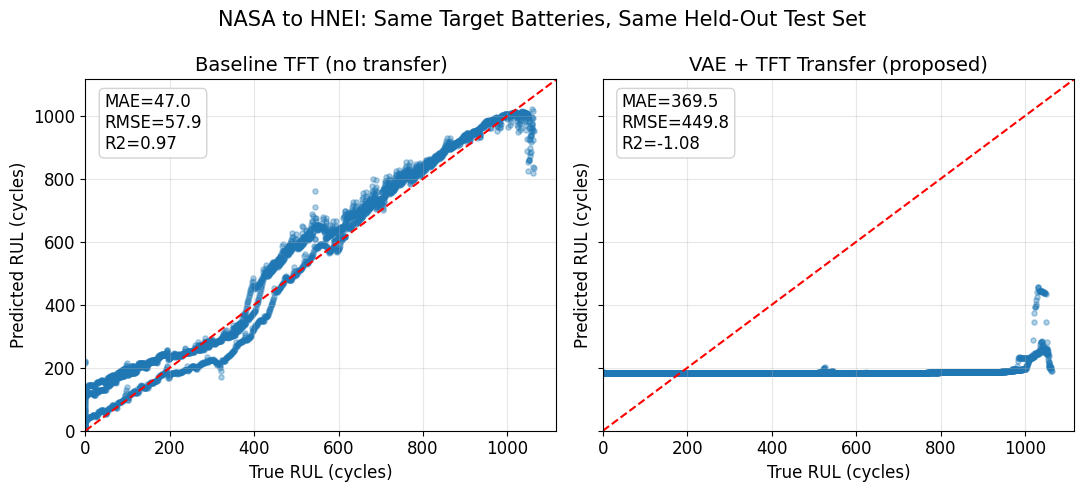

Saved main figure to figures/tft_vae_main_nasa_to_hnei_baseline_vs_transfer.png


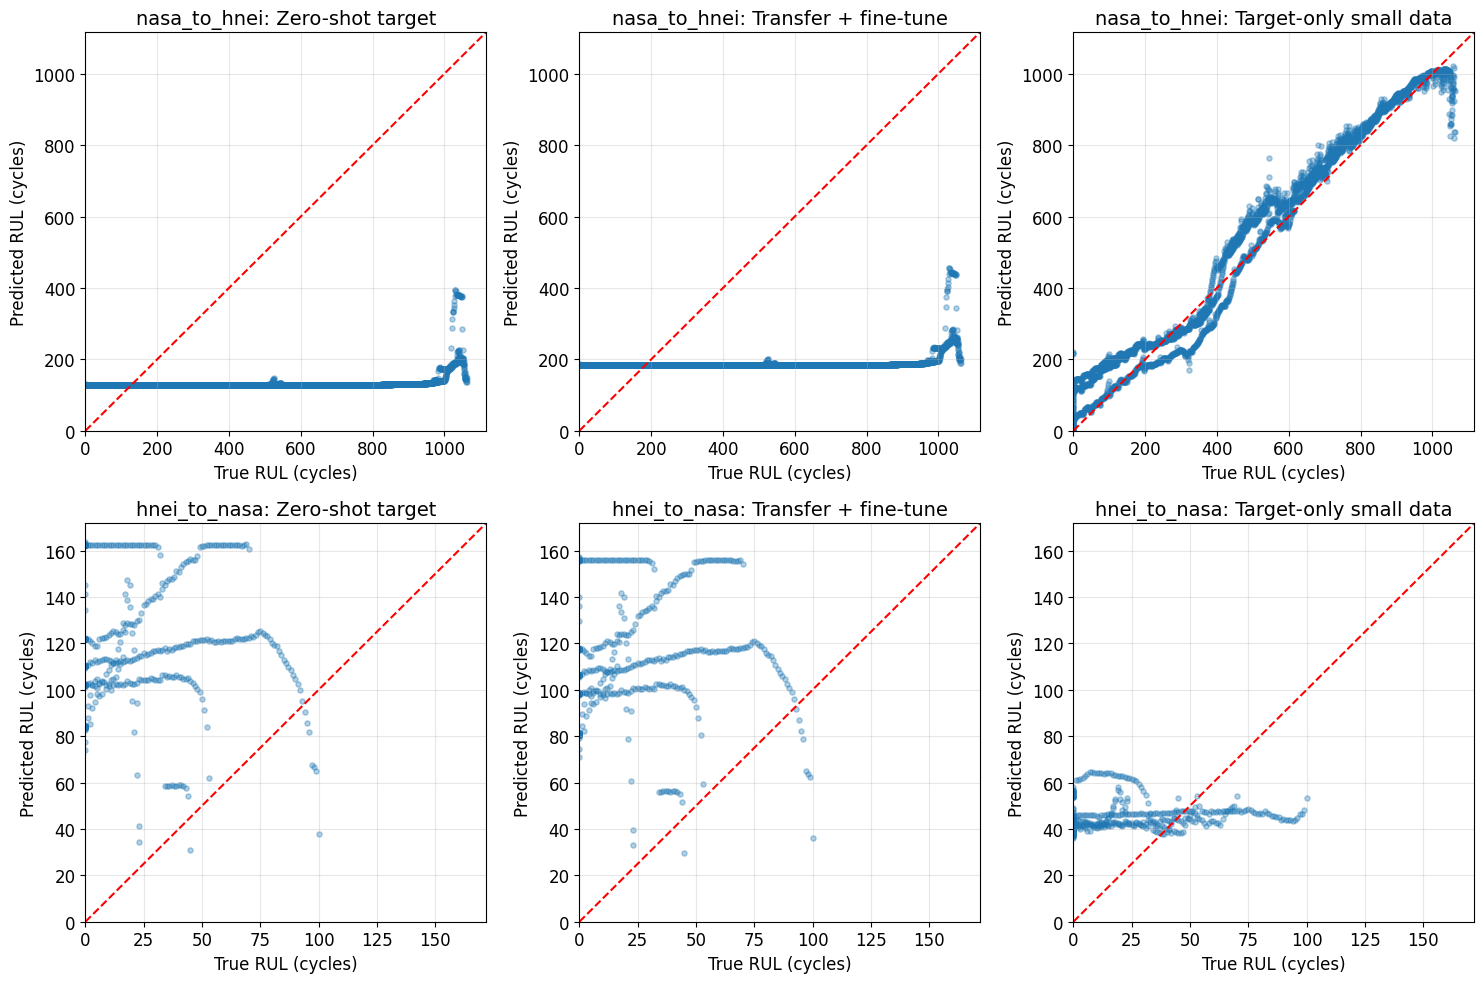

Saved supplementary plot to figures/tft_vae_supplementary_all_directions.png


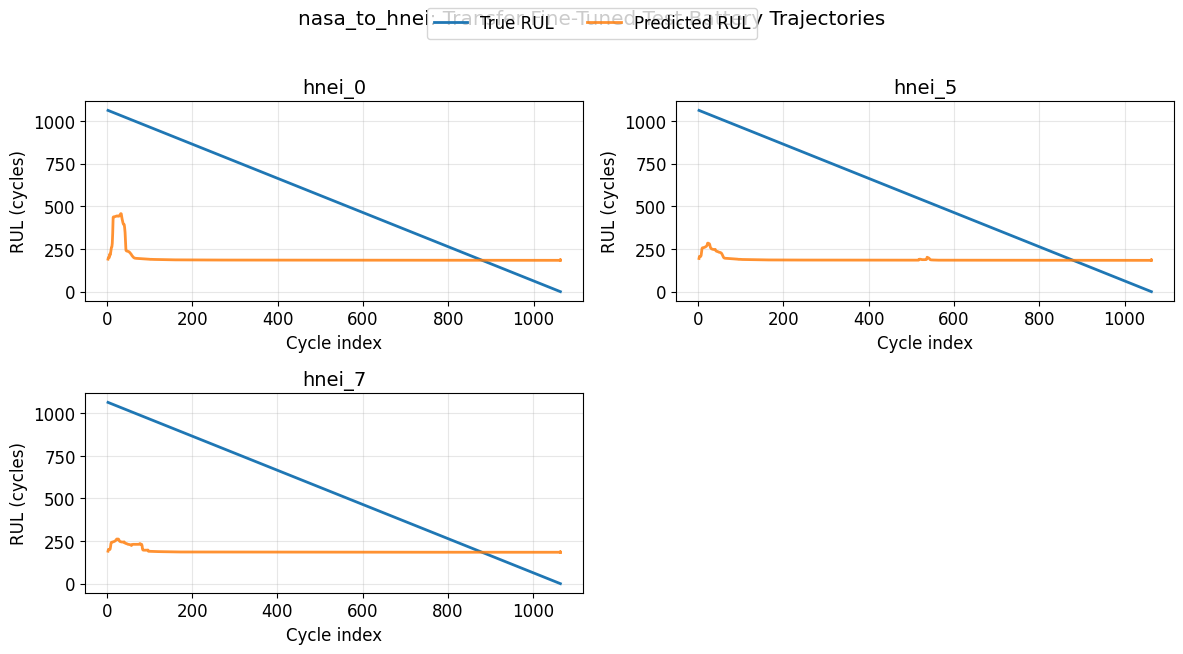

Saved trajectory plot to figures/nasa_to_hnei_target_fine_tuned_random_test_batteries.png


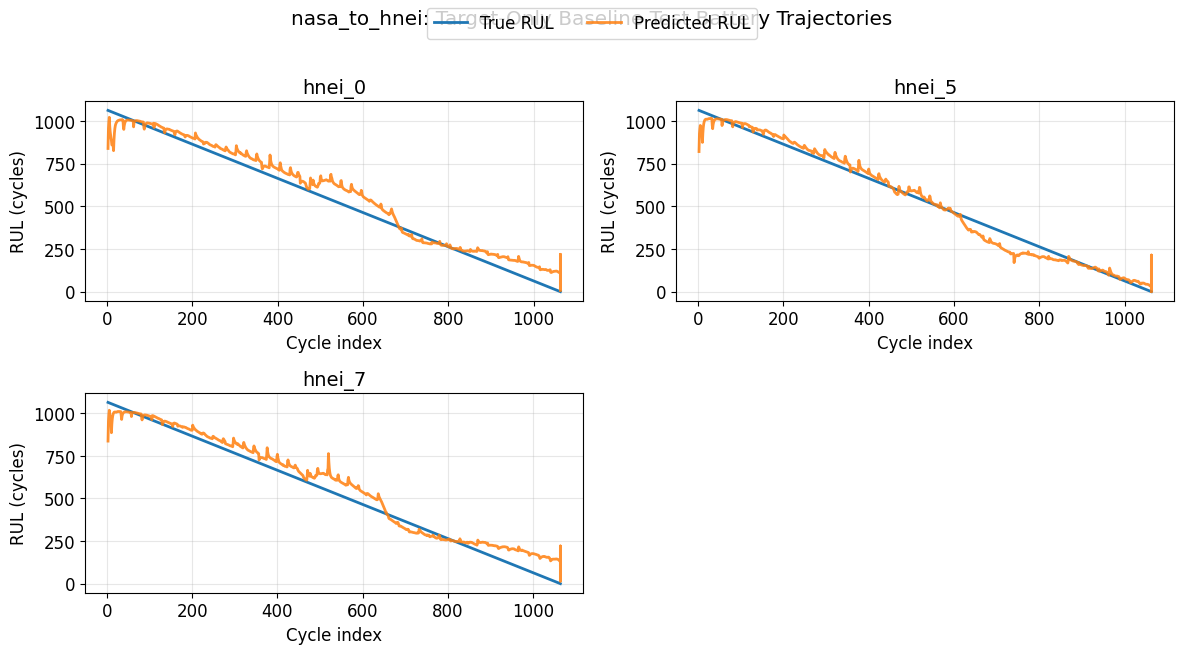

Saved trajectory plot to figures/nasa_to_hnei_target_only_small_data_random_test_batteries.png


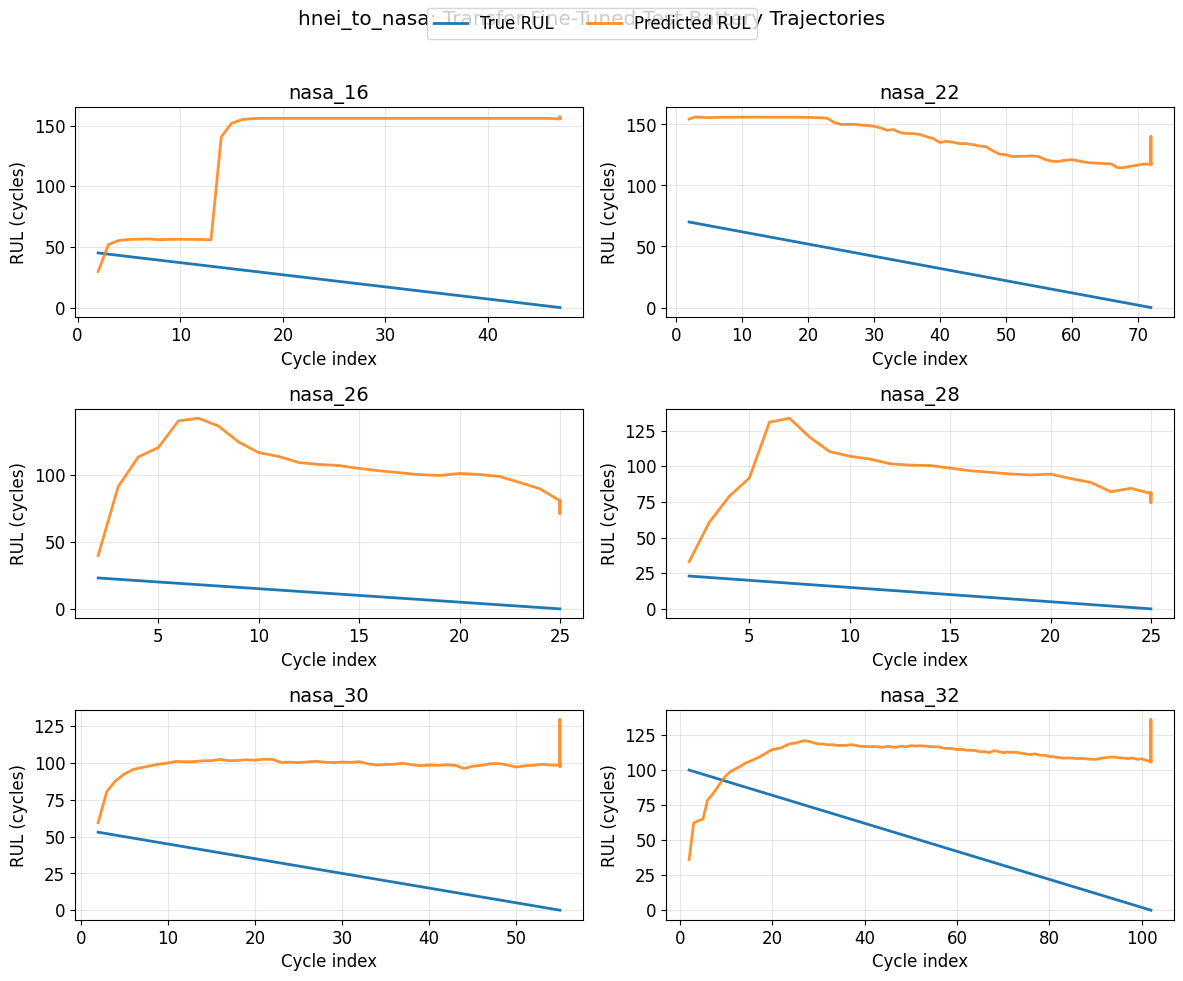

Saved trajectory plot to figures/hnei_to_nasa_target_fine_tuned_random_test_batteries.png


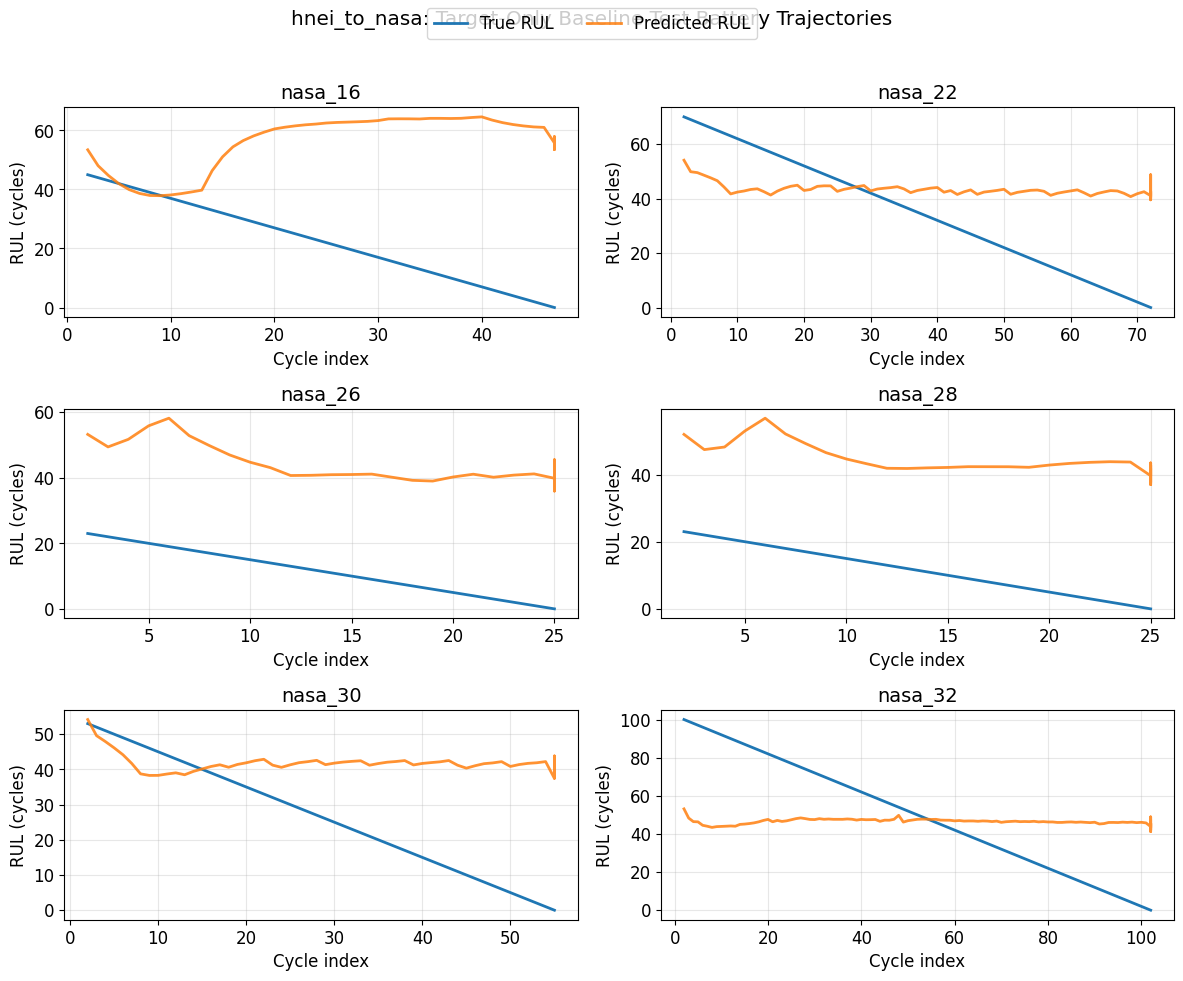

Saved trajectory plot to figures/hnei_to_nasa_target_only_small_data_random_test_batteries.png


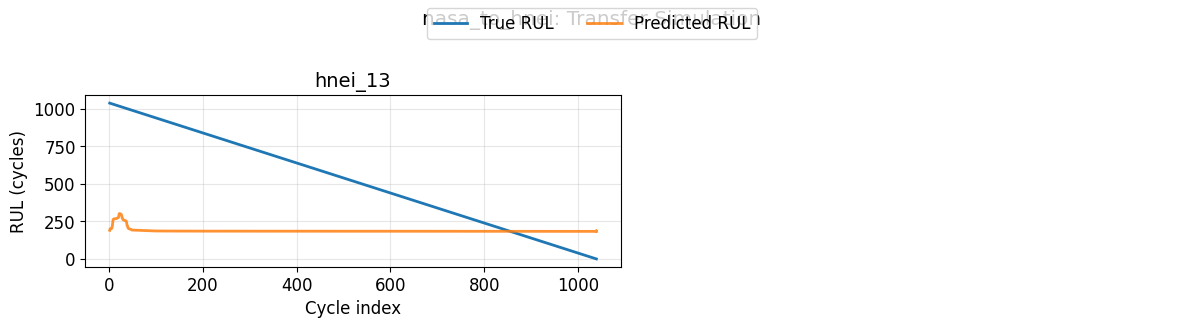

Saved trajectory plot to figures/nasa_to_hnei_target_simulation_transfer_trajectory.png


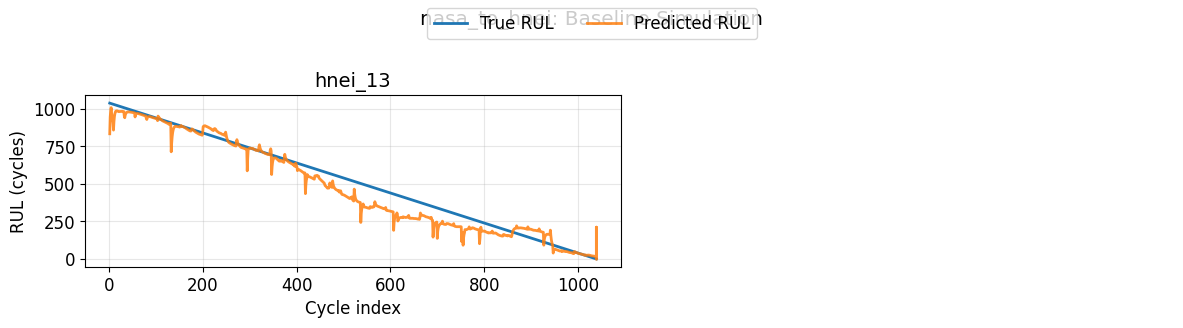

Saved trajectory plot to figures/nasa_to_hnei_target_simulation_baseline_trajectory.png


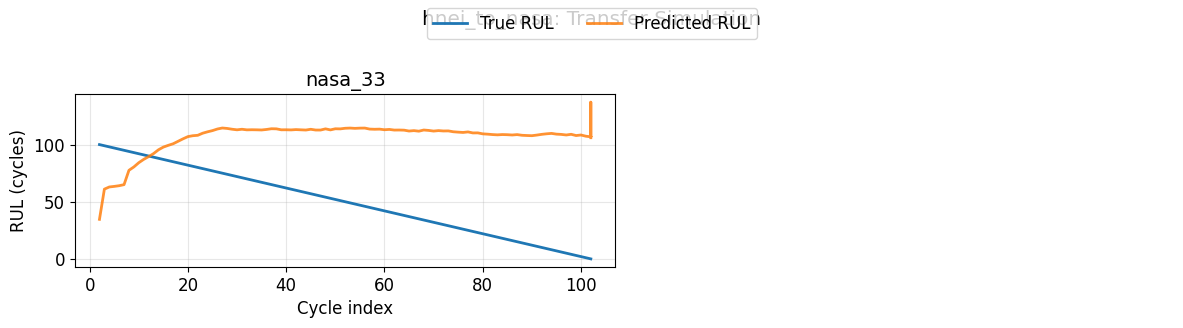

Saved trajectory plot to figures/hnei_to_nasa_target_simulation_transfer_trajectory.png


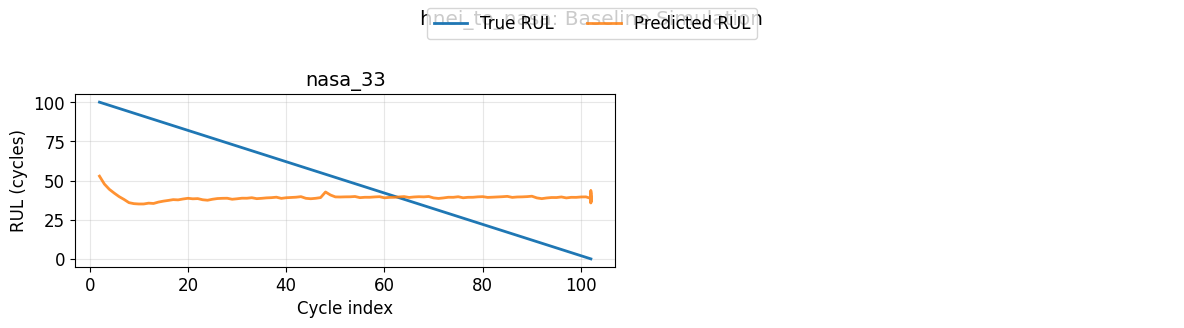

Saved trajectory plot to figures/hnei_to_nasa_target_simulation_baseline_trajectory.png


In [41]:
def plot_main_baseline_vs_transfer(experiments: list[dict[str, object]]) -> None:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    main_direction_name = f"{MAIN_DIRECTION[0]}_to_{MAIN_DIRECTION[1]}"
    exp = next(exp for exp in experiments if exp["direction"] == main_direction_name)

    panels = [
        ("Baseline TFT (no transfer)", "target_only_metrics"),
        ("VAE + TFT Transfer (proposed)", "transfer_metrics"),
    ]

    all_actuals = np.concatenate([exp[key]["actuals"] for _, key in panels])
    all_preds = np.concatenate([exp[key]["preds"] for _, key in panels])
    lower = float(min(all_actuals.min(), all_preds.min()))
    upper = float(max(all_actuals.max(), all_preds.max()))
    pad = 0.05 * (upper - lower) if upper > lower else 1.0
    lower = max(0.0, lower - pad)
    upper = upper + pad

    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    })
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

    for ax, (title, key) in zip(axes, panels):
        metrics = exp[key]
        ax.scatter(metrics["actuals"], metrics["preds"], alpha=0.35, s=14)
        ax.plot([lower, upper], [lower, upper], "--", color="red", linewidth=1.5)
        ax.set_xlim(lower, upper)
        ax.set_ylim(lower, upper)
        ax.set_xlabel("True RUL (cycles)")
        ax.set_ylabel("Predicted RUL (cycles)")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.text(
            0.04,
            0.96,
            f"MAE={metrics['mae']:.1f}\nRMSE={metrics['rmse']:.1f}\nR2={metrics['r2']:.2f}",
            transform=ax.transAxes,
            va="top",
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
        )

    fig.suptitle("NASA to HNEI: Same Target Batteries, Same Held-Out Test Set", fontsize=15)
    plt.tight_layout()
    path = FIGURE_DIR / "tft_vae_main_nasa_to_hnei_baseline_vs_transfer.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved main figure to {path}")


def plot_supplementary_transfer_predictions(experiments: list[dict[str, object]]) -> None:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    panels = [
        ("Zero-shot target", "zero_shot_metrics"),
        ("Transfer + fine-tune", "transfer_metrics"),
        ("Target-only small data", "target_only_metrics"),
    ]
    fig, axes = plt.subplots(len(experiments), len(panels), figsize=(5 * len(panels), 5 * len(experiments)))
    if len(experiments) == 1:
        axes = np.array([axes])

    for row, exp in enumerate(experiments):
        all_actuals = np.concatenate([exp[key]["actuals"] for _, key in panels])
        all_preds = np.concatenate([exp[key]["preds"] for _, key in panels])
        lower = float(min(all_actuals.min(), all_preds.min()))
        upper = float(max(all_actuals.max(), all_preds.max()))
        pad = 0.05 * (upper - lower) if upper > lower else 1.0
        lower = max(0.0, lower - pad)
        upper = upper + pad
        for col, (title, key) in enumerate(panels):
            metrics = exp[key]
            ax = axes[row, col]
            ax.scatter(metrics["actuals"], metrics["preds"], alpha=0.35, s=14)
            ax.plot([lower, upper], [lower, upper], "--", color="red", linewidth=1.5)
            ax.set_xlim(lower, upper)
            ax.set_ylim(lower, upper)
            ax.set_xlabel("True RUL (cycles)")
            ax.set_ylabel("Predicted RUL (cycles)")
            ax.set_title(f"{exp['direction']}: {title}")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = FIGURE_DIR / "tft_vae_supplementary_all_directions.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved supplementary plot to {path}")


def plot_battery_trajectories(
    prediction_df: pd.DataFrame,
    title: str,
    path: Path,
    max_batteries: int = 8,
    seed: int = SEED,
) -> None:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    batteries = np.array(sorted(prediction_df["battery_id"].unique()))
    if len(batteries) == 0:
        print(f"No batteries available for {title}")
        return
    rng = np.random.default_rng(seed)
    sample_size = min(max_batteries, len(batteries))
    sampled = sorted(rng.choice(batteries, size=sample_size, replace=False))

    ncols = 2
    nrows = math.ceil(sample_size / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows), squeeze=False)
    for ax, battery_id in zip(axes.ravel(), sampled):
        part = prediction_df[prediction_df["battery_id"] == battery_id].sort_values("time_idx")
        ax.plot(part["time_idx"], part["true_rul"], label="True RUL", linewidth=2)
        ax.plot(part["time_idx"], part["pred_rul"], label="Predicted RUL", linewidth=2, alpha=0.85)
        ax.set_title(str(battery_id))
        ax.set_xlabel("Cycle index")
        ax.set_ylabel("RUL (cycles)")
        ax.grid(True, alpha=0.3)
    for ax in axes.ravel()[sample_size:]:
        ax.axis("off")
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved trajectory plot to {path}")


def plot_random_test_battery_trajectories(experiments: list[dict[str, object]]) -> None:
    for exp in experiments:
        for title_suffix, key in [
            ("Transfer Fine-Tuned", "transfer_metrics"),
            ("Target-Only Baseline", "target_only_metrics"),
        ]:
            stage_df = exp[key]["prediction_df"]
            path = FIGURE_DIR / f"{exp['direction']}_{exp[key]['stage']}_random_test_batteries.png"
            plot_battery_trajectories(
                stage_df,
                f"{exp['direction']}: {title_suffix} Test Battery Trajectories",
                path,
                max_batteries=8,
            )


def plot_simulation_trajectories(experiments: list[dict[str, object]]) -> None:
    for exp in experiments:
        for title_suffix, key in [
            ("Transfer Simulation", "simulation_transfer_metrics"),
            ("Baseline Simulation", "simulation_baseline_metrics"),
        ]:
            stage_df = exp[key]["prediction_df"]
            path = FIGURE_DIR / f"{exp['direction']}_{exp[key]['stage']}_trajectory.png"
            plot_battery_trajectories(
                stage_df,
                f"{exp['direction']}: {title_suffix}",
                path,
                max_batteries=8,
            )


plot_main_baseline_vs_transfer(experiments)
plot_supplementary_transfer_predictions(experiments)
plot_random_test_battery_trajectories(experiments)
plot_simulation_trajectories(experiments)


## Final Run Summary

Run after training, metrics, and plots to print the final experiment artifacts and safeguards.


In [42]:
print("Final pipeline summary")
print(f"Order-based TFT window: min_encoder_length=1, max_encoder_length={MAX_ENCODER_LENGTH}, max_prediction_length={MAX_PREDICTION_LENGTH}")
print(f"VAE window length: {VAE_WINDOW_LENGTH}")
print(f"Simulation batteries: {simulation_battery_ids}")
print("Shortcut checks:")
print("  cycle_scaled absent:", "cycle_scaled" not in globals())
print("  MODEL_TIME_COL absent:", "MODEL_TIME_COL" not in globals())
print("  time_varying_known_reals is [] in make_tft_datasets")

for exp in experiments:
    print("-" * 80)
    print(exp["direction"])
    print("  source feature scaler fit batteries:", list(exp["source_feature_scaler"]["fit_battery_ids"]))
    print("  target feature scaler fit batteries:", list(exp["target_feature_scaler"]["fit_battery_ids"]))
    print("  source target scaler fit batteries:", list(exp["source_scaler"]["fit_battery_ids"]))
    print("  target target scaler fit batteries:", list(exp["target_scaler"]["fit_battery_ids"]))
    print("  target simulation batteries:", exp["target_simulation_battery_ids"])
    print("  VAE checkpoint:", exp["source_vae_checkpoint"])
    print("  source TFT best/last:", exp["source_tft_best_checkpoint"], exp["source_tft_last_checkpoint"])
    print("  transfer TFT best/last:", exp["transfer_tft_best_checkpoint"], exp["transfer_tft_last_checkpoint"])
    print("  target-only TFT best/last:", exp["target_only_tft_best_checkpoint"], exp["target_only_tft_last_checkpoint"])

print("Saved CSVs:")
for name, path in csv_paths.items():
    print(f"  {name}: {path}")
print("Saved figures directory:", FIGURE_DIR)
print("Model checkpoint directory:", CHECKPOINT_DIR)


Final pipeline summary
Order-based TFT window: min_encoder_length=1, max_encoder_length=20, max_prediction_length=1
VAE window length: 20
Simulation batteries: {'hnei': 'hnei_13', 'nasa': 'nasa_33'}
Shortcut checks:
  cycle_scaled absent: True
  MODEL_TIME_COL absent: True
  time_varying_known_reals is [] in make_tft_datasets
--------------------------------------------------------------------------------
nasa_to_hnei
  source feature scaler fit batteries: ['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_17', 'nasa_18', 'nasa_21', 'nasa_23', 'nasa_24', 'nasa_25', 'nasa_29', 'nasa_3', 'nasa_31', 'nasa_4', 'nasa_5', 'nasa_6', 'nasa_7', 'nasa_8', 'nasa_9']
  target feature scaler fit batteries: ['hnei_1', 'hnei_3', 'hnei_6']
  source target scaler fit batteries: ['nasa_0', 'nasa_1', 'nasa_12', 'nasa_13', 'nasa_14', 'nasa_15', 'nasa_17', 'nasa_18', 'nasa_21', 'nasa_23', 'nasa_24', 'nasa_25', 'nasa_29', 'nasa_3', 'nasa_31', 'nasa_4', 'nasa_5', 'nasa_6', 'nasa_7', 'nasa